# Token Distribution Analysis

Analyze per-expert and per-rank token load distributions from expert load dumps.

**Prerequisites:** Collect results with `just eplb-collect <run-name>` before running this notebook.
Each run lives in `benchmarks/eplb/<run-name>/` with `expert-load/` dumps.

In [60]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from eplb_analysis import (
    load_run,
    load_config,
    list_runs,
    ExpertLoadData,
    plot_expert_load_heatmap,
    plot_rank_balance_at_steps,
    plot_expert_popularity,
    plot_balancedness_over_time,
)
# plot_expert_popularity is reused directly in section 3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.3f}".format)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Select Run

In [ ]:
RESULTS_ROOT = Path("./blog_results")  # search recursively under this path

# --- Filters (set to None to disable) ---
FILTER_NUM_REDUNDANT = None   # e.g. 0, 32, 128 — exact match
FILTER_EPLB_EFFECTIVE = False   # True = EPLB actually rebalanced, False = off/stats-only
FILTER_MODEL="DeepSeek-R1-0528-NVFP4-v2"

# Discover all run directories that contain expert-load dumps
def _discover_expert_load_runs(root: Path):
    """Walk root recursively for dirs with config.env + expert-load/."""
    root = Path(root)
    rows = []
    for config_path in sorted(root.rglob("config.env")):
        run_dir = config_path.parent
        expert_dir = run_dir / "expert-load"
        has_expert_load = expert_dir.exists() and any(expert_dir.rglob("*_expert_load.json*"))
        if not has_expert_load:
            continue
        # results_dir is the parent of the run dir (e.g. ./default_load/)
        rdir = str(run_dir.parent)
        name = run_dir.name
        cfg = load_config(name, rdir)
        rows.append({
            "results_dir": rdir,
            "name": name,
            "mode": cfg.mode,
            "model": cfg.model_short,
            "eplb_cfg": cfg.eplb_mode,
            "eplb_effective": cfg.effective_eplb_mode,
            "eplb_scope": cfg.eplb_scope,
            "num_redundant": cfg.num_redundant,
            "topology": cfg.topology_str,
            "dataset": cfg.dataset,
        })
    return pd.DataFrame(rows)

runs_df = _discover_expert_load_runs(RESULTS_ROOT)

# Apply filters
if FILTER_MODEL is not None:
    runs_df = runs_df[runs_df["model"] == FILTER_MODEL]
if FILTER_NUM_REDUNDANT is not None:
    runs_df = runs_df[runs_df["num_redundant"] == FILTER_NUM_REDUNDANT]
if FILTER_EPLB_EFFECTIVE is not None:
    if FILTER_EPLB_EFFECTIVE:
        runs_df = runs_df[runs_df["eplb_effective"] != "off"]
    else:
        runs_df = runs_df[runs_df["eplb_effective"] == "off"]

print(f"Found {len(runs_df)} runs with expert-load data:")
runs_df

Found 5 runs with expert-load data:


,results_dir,name,mode,model,eplb_cfg,eplb_effective,eplb_scope,num_redundant,topology,dataset
0,blog_results,pd-baseline-lmsys-stats-r0,pd,DeepSeek-R1-0528-NVFP4-v2,async,off,decode,0,P=2 D=8,lmsys-chat-1m
1,blog_results,pd-baseline-lmsys-stats-r0-v1,pd,DeepSeek-R1-0528-NVFP4-v2,async,off,decode,0,P=3 D=8,lmsys-chat-1m
2,blog_results,pd-baseline-sharegpt-stats-r0,pd,DeepSeek-R1-0528-NVFP4-v2,async,off,decode,0,P=2 D=8,sharegpt
3,blog_results,pd-baseline-sharegpt-stats-r0-v1,pd,DeepSeek-R1-0528-NVFP4-v2,async,off,decode,0,P=3 D=8,sharegpt
4,blog_results,pd-baseline-starcoder-stats-r0,pd,DeepSeek-R1-0528-NVFP4-v2,async,off,decode,0,P=2 D=8,starcoderdata


In [72]:
# Pick a run from the table above (row index or set name + results_dir directly)
ROW_IDX = 3  # <-- index into runs_df above

selected = runs_df.iloc[ROW_IDX]
RUN_NAME = selected["name"]
results_dir = selected["results_dir"]

run = load_run(RUN_NAME, results_dir)
cfg = run.config

print(f"Run:       {run.name}  (from {results_dir})")
print(f"Mode:      {cfg.mode}")
print(f"Model:     {cfg.model_short}")
print(f"EPLB:      {cfg.eplb_mode} (scope: {cfg.eplb_scope})")
print(f"Effective: {run.effective_eplb_mode}")
print(f"Topology:  {cfg.topology_str}")
print(f"Redundant: {cfg.num_redundant}")
print(f"Expert load keys: {list(run.expert_loads.keys())}")

Run:       pd-baseline-sharegpt-stats-r0-v1  (from blog_results)
Mode:      pd
Model:     DeepSeek-R1-0528-NVFP4-v2
EPLB:      async (scope: decode)
Effective: off
Topology:  P=3 D=8
Redundant: 0
Expert load keys: ['decode/nvidia_DeepSeek-R1-0528-NVFP4-v2_expert_load']


## 2. Select Expert Load & Snapshot

In [73]:
# Pick the first available expert load dump (or set explicitly)
load_key = list(run.expert_loads.keys())[0]
d: ExpertLoadData = run.expert_loads[load_key]

print(f"Load key:          {load_key}")
print(f"World size (EP):   {d.world_size}")
print(f"Layers (MoE):      {d.num_layers}")
print(f"Physical experts:  {d.num_physical}")
print(f"Logical experts:   {d.num_logical}")
print(f"Redundant experts: {d.num_redundant}")
print(f"Experts per rank:  {d.experts_per_rank}")
print(f"Snapshots:         {d.num_snapshots}")
print(f"Step range:        {d.steps[0]} .. {d.steps[-1]}")

Load key:          decode/nvidia_DeepSeek-R1-0528-NVFP4-v2_expert_load
World size (EP):   32
Layers (MoE):      58
Physical experts:  256
Logical experts:   256
Redundant experts: 0
Experts per rank:  8
Snapshots:         173
Step range:        100 .. 17300


In [74]:
SNAPSHOT_IDX = 100  # -1 = last snapshot

snap, load, p2l_map = d.snapshot(SNAPSHOT_IDX)
print(f"Snapshot step: {snap['step']}")
print(f"Load shape:    {load.shape}  (layers x physical_experts)")

Snapshot step: 10100
Load shape:    (58, 256)  (layers x physical_experts)


## 3. Per-Expert Token Histogram

Distribution of total tokens routed to each physical expert (summed across all MoE layers).

Expert load: mean=3799232, std=278541, max/mean=1.25x


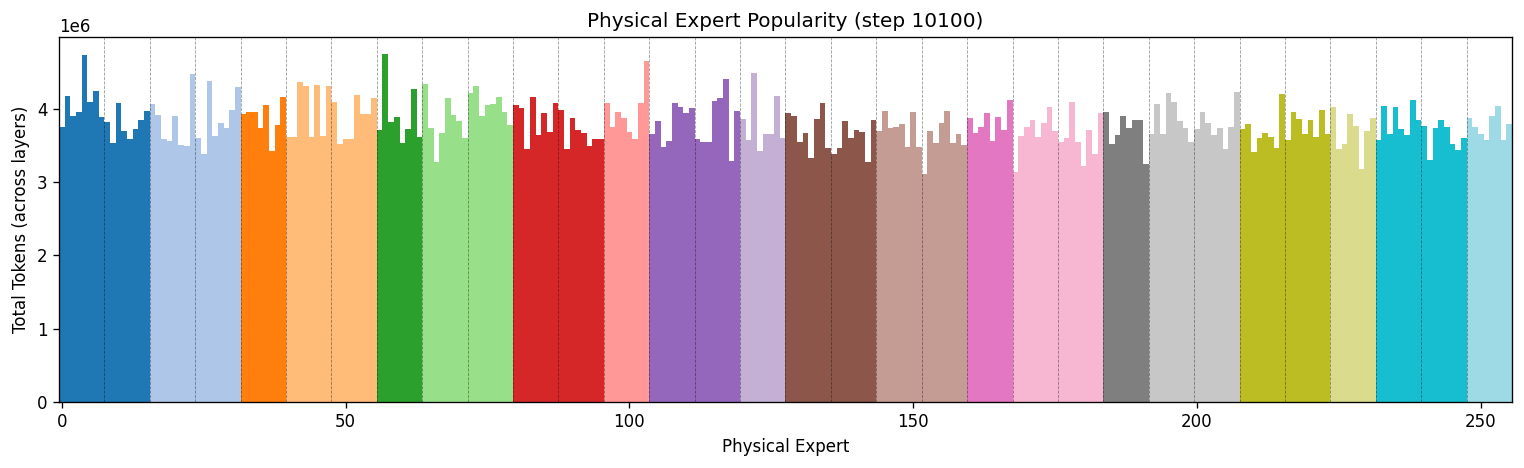

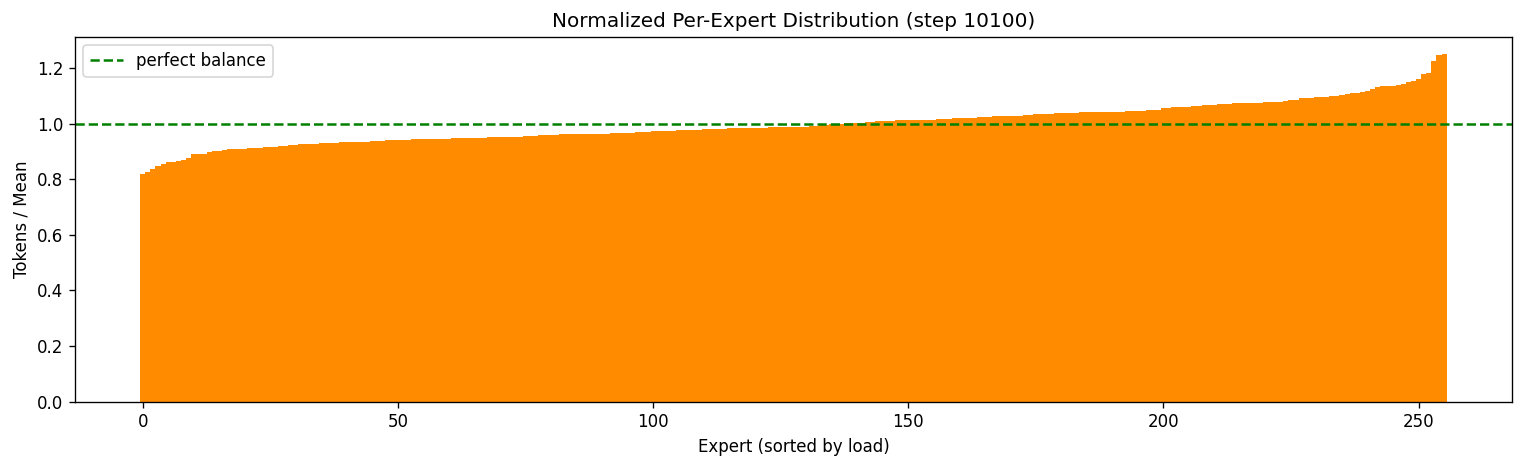

In [75]:
plot_expert_popularity(d, SNAPSHOT_IDX)

# Sorted normalized view
tokens_per_expert = load.sum(axis=0)
normalized = np.sort(tokens_per_expert / tokens_per_expert.mean())

fig, ax = plt.subplots(figsize=(max(12, d.num_physical * 0.05), 4))
ax.bar(np.arange(d.num_physical), normalized, color="darkorange", width=1.0, edgecolor="none")
ax.axhline(1.0, color="green", linestyle="--", label="perfect balance")
ax.set_xlabel("Expert (sorted by load)")
ax.set_ylabel("Tokens / Mean")
ax.set_title(f"Normalized Per-Expert Distribution (step {snap['step']})")
ax.legend()
plt.tight_layout()

## 4. Per-Rank Token Histogram

Distribution of total tokens per EP rank (summed across layers and experts within rank).

Ranks: 32
Mean: 30393856  Std: 960429  CoV: 0.032
Min: 28823163 (R17)  Max: 32760320 (R0)  Max/Mean: 1.08x


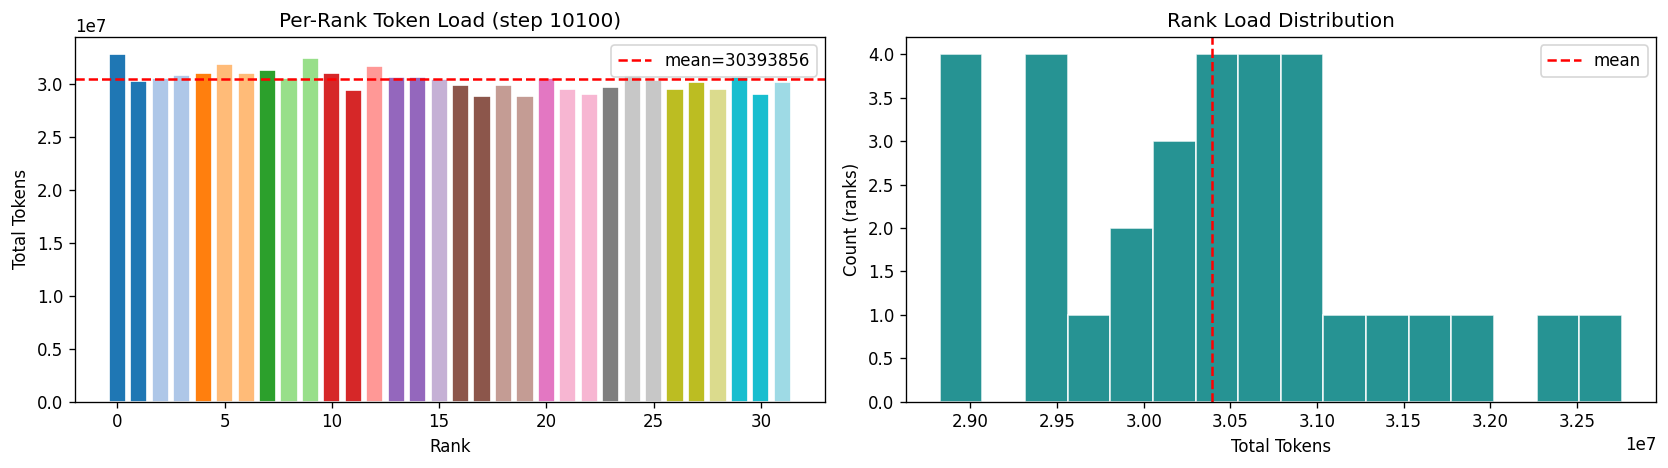

In [76]:
rank_load_per_layer = load.reshape(d.num_layers, d.world_size, d.experts_per_rank).sum(axis=2)
tokens_per_rank = rank_load_per_layer.sum(axis=0)  # shape: (world_size,)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart: tokens per rank
colors = [plt.cm.tab20(r / d.world_size) for r in range(d.world_size)]
axes[0].bar(range(d.world_size), tokens_per_rank, color=colors, edgecolor="white")
axes[0].axhline(tokens_per_rank.mean(), color="red", linestyle="--", label=f"mean={tokens_per_rank.mean():.0f}")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Total Tokens")
axes[0].set_title(f"Per-Rank Token Load (step {snap['step']})")
axes[0].legend()

# Histogram: rank load distribution
n_bins = max(10, d.world_size // 2)
axes[1].hist(tokens_per_rank, bins=n_bins, color="teal", edgecolor="white", alpha=0.85)
axes[1].axvline(tokens_per_rank.mean(), color="red", linestyle="--", label=f"mean")
axes[1].set_xlabel("Total Tokens")
axes[1].set_ylabel("Count (ranks)")
axes[1].set_title("Rank Load Distribution")
axes[1].legend()

plt.tight_layout()

print(f"Ranks: {d.world_size}")
print(f"Mean: {tokens_per_rank.mean():.0f}  Std: {tokens_per_rank.std():.0f}  "
      f"CoV: {tokens_per_rank.std() / tokens_per_rank.mean():.3f}")
print(f"Min: {tokens_per_rank.min():.0f} (R{tokens_per_rank.argmin()})  "
      f"Max: {tokens_per_rank.max():.0f} (R{tokens_per_rank.argmax()})  "
      f"Max/Mean: {tokens_per_rank.max() / tokens_per_rank.mean():.2f}x")

## 5. Expert Load Heatmap

Load matrix `[layers x physical_experts]` with rank boundaries.

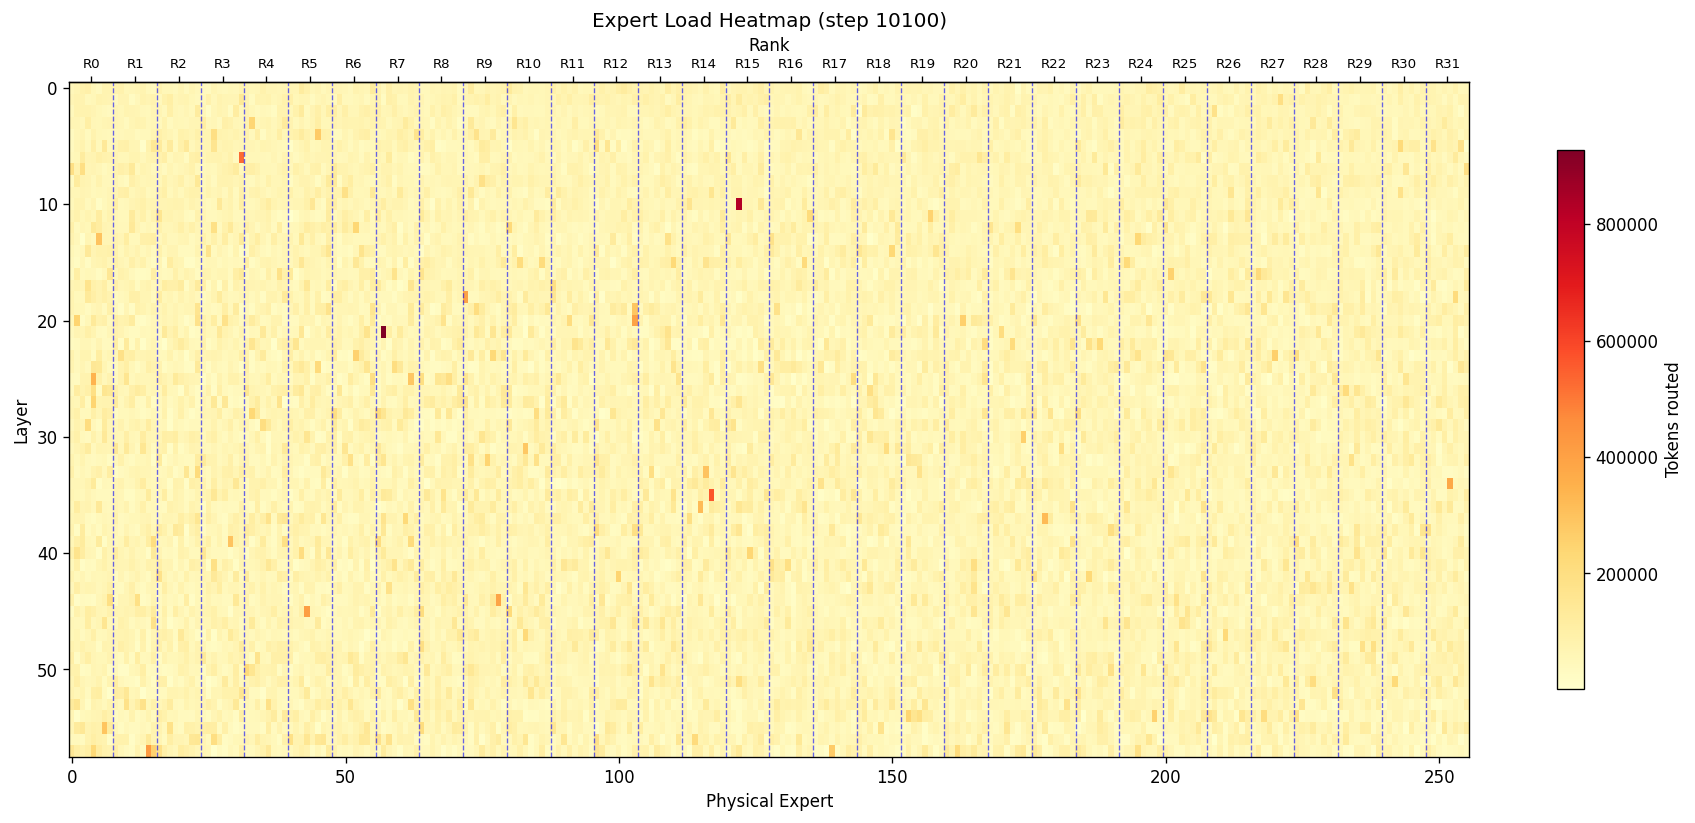

In [77]:
plot_expert_load_heatmap(d, SNAPSHOT_IDX)

## 6. Rank Balance Heatmap + Per-Layer Balancedness

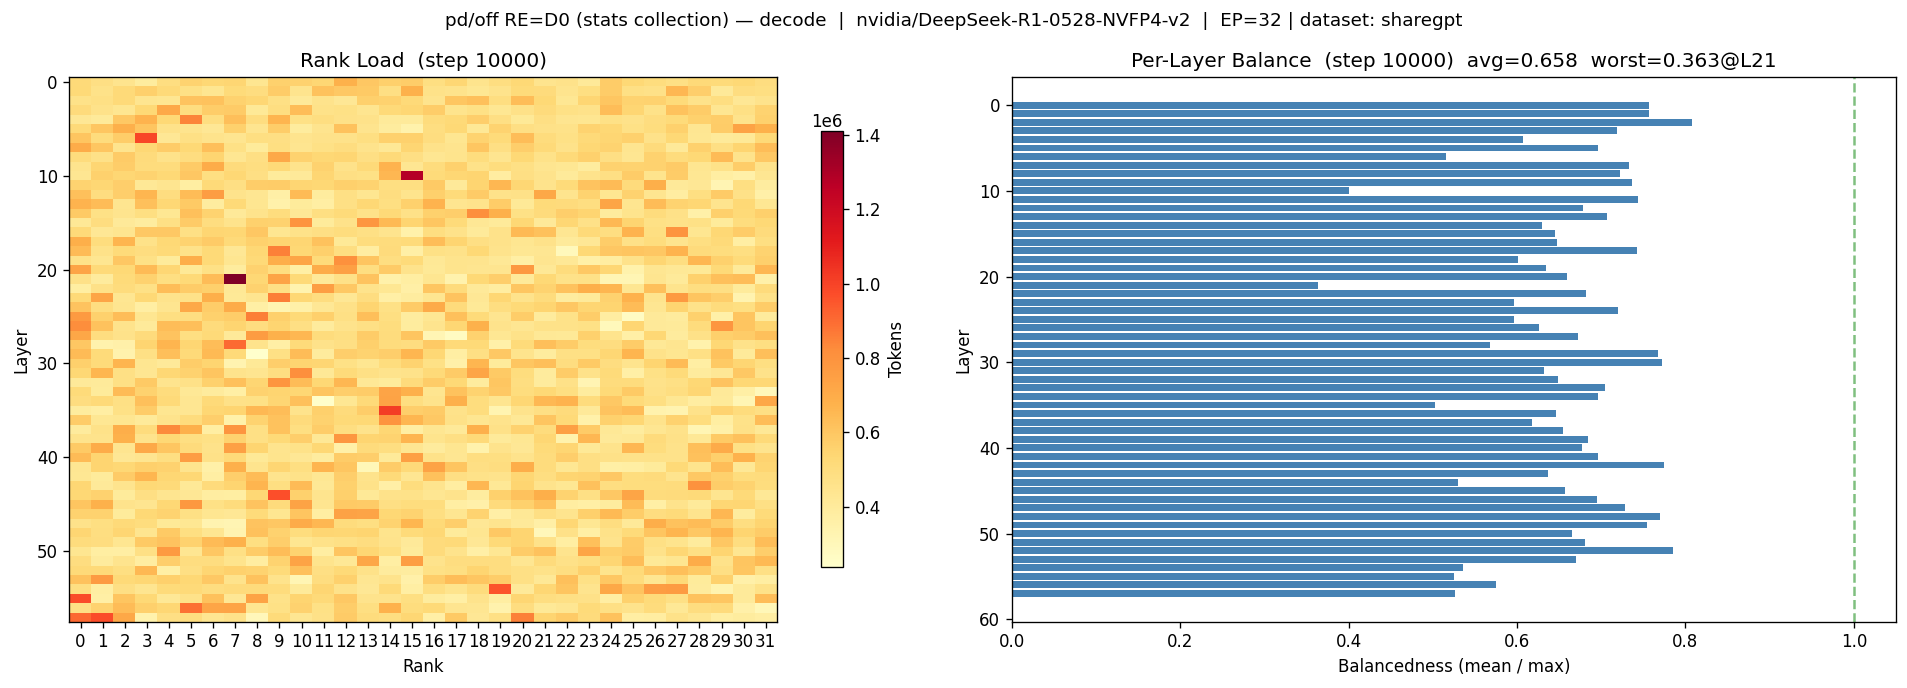

In [78]:
plot_rank_balance_at_steps(run, steps=[10000], role="decode")

## 8. Balancedness Over Time

Track how balance evolves across all snapshots (vLLM metric, mean, and worst layer).

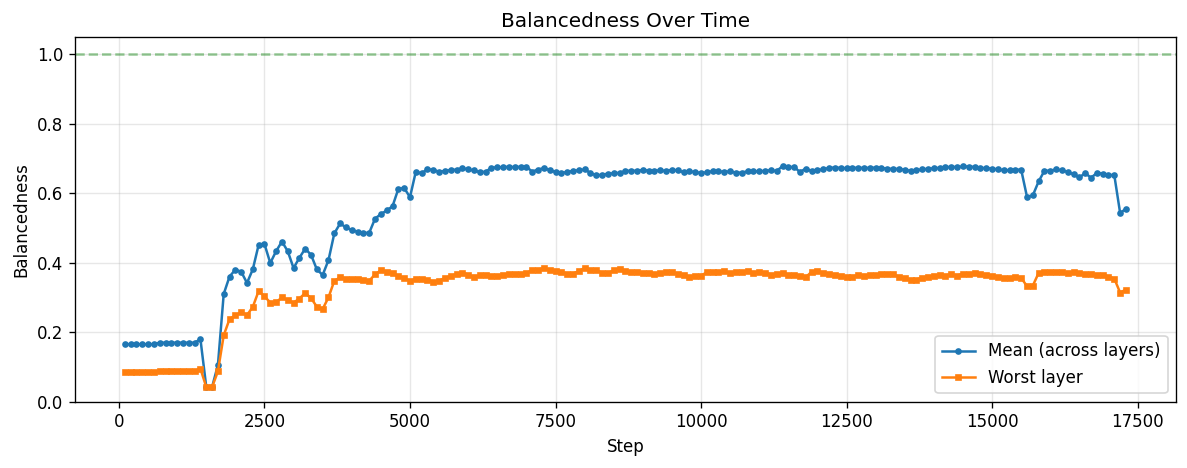

In [79]:
plot_balancedness_over_time(d)

## 9. Per-Layer Token Histograms

Token distribution across experts for selected layers (first, middle, last, best-balanced, worst-balanced).

Aggregate metrics hide per-layer variation — the **worst-balanced layer** gates the slowest rank in that layer's all-to-all and dominates latency. Comparing best vs worst shows the spread and whether imbalance is structural (same layer every time) or transient.

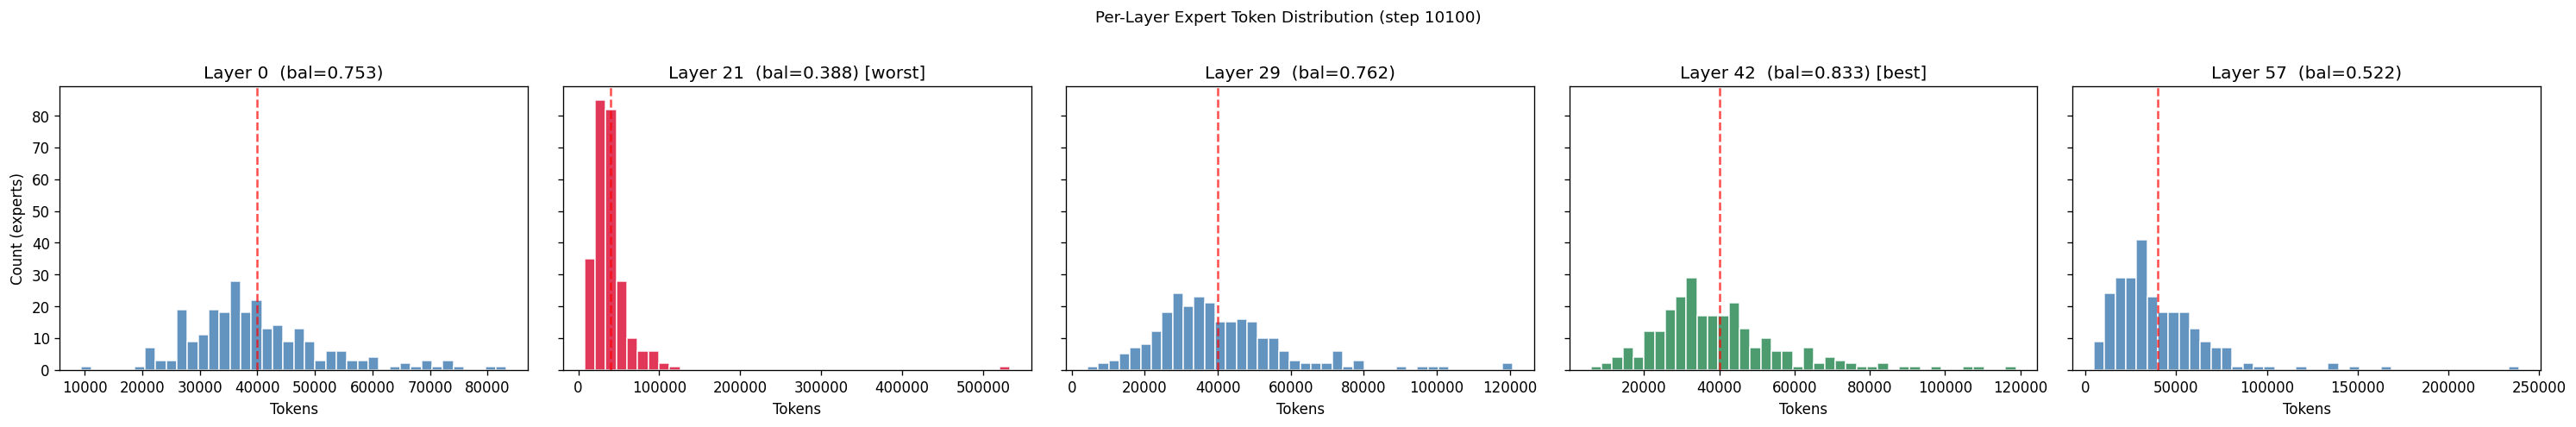

In [51]:
# Pick layers to inspect: first, middle, last, and the worst-balanced layer
mean_load_per_layer = rank_load_per_layer.mean(axis=1)
max_load_per_layer = rank_load_per_layer.max(axis=1)
layer_balancedness = np.where(max_load_per_layer > 0, mean_load_per_layer / max_load_per_layer, 0.0)
worst_layer = int(layer_balancedness.argmin())
best_layer = int(layer_balancedness.argmax())

sample_layers = sorted(set([0, d.num_layers // 2, d.num_layers - 1, worst_layer, best_layer]))

fig, axes = plt.subplots(1, len(sample_layers), figsize=(5 * len(sample_layers), 4), sharey=True)
if len(sample_layers) == 1:
    axes = [axes]

LAYER_COLORS = {worst_layer: "crimson", best_layer: "seagreen"}

for ax, layer_idx in zip(axes, sample_layers):
    layer_load = load[layer_idx]  # shape: (num_physical,)
    color = LAYER_COLORS.get(layer_idx, "steelblue")
    ax.hist(layer_load, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(layer_load.mean(), color="red", linestyle="--", alpha=0.7)
    bal = layer_balancedness[layer_idx]
    tag = ""
    if layer_idx == worst_layer:
        tag = " [worst]"
    elif layer_idx == best_layer:
        tag = " [best]"
    ax.set_title(f"Layer {layer_idx}  (bal={bal:.3f}){tag}")
    ax.set_xlabel("Tokens")

axes[0].set_ylabel("Count (experts)")
fig.suptitle(f"Per-Layer Expert Token Distribution (step {snap['step']})", fontsize=11, y=1.02)
plt.tight_layout()

## 10. Summary Statistics

In [80]:
def gini(x):
    """Gini coefficient: 0 = perfect equality, 1 = maximum inequality."""
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) / (n * np.sum(x))) - (n + 1) / n


def distribution_stats(values, name):
    mu = values.mean()
    return {
        "scope": name,
        "count": len(values),
        "mean": mu,
        "std": values.std(),
        "CoV": values.std() / mu if mu > 0 else np.nan,
        "min": values.min(),
        "max": values.max(),
        "max/mean": values.max() / mu if mu > 0 else np.nan,
        "Gini": gini(values),
    }


stats = pd.DataFrame([
    distribution_stats(tokens_per_expert, "per-expert"),
    distribution_stats(tokens_per_rank, "per-rank"),
]).set_index("scope")

stats

,count,mean,std,CoV,min,max,max/mean,Gini
scope,,,,,,,,
per-expert,256,3799232.000,278541.444,0.073,3116262,4746725,1.249,0.041
per-rank,32,30393856.000,960429.007,0.032,28823163,32760320,1.078,0.018


In [23]:
def compute_linear_eplb_speedup(T, W, E_R):
    """
    Computes the exact speedup for a specific distribution vector T
    where the baseline has a linear (sequential) placement of experts across GPUs.
    
    Parameters:
    -----------
    T : list or np.ndarray
        The input token counts for each logical expert (length 256) in their 
        original physical/logical order.
    W : int
        World size / number of GPUs (e.g., 16 or 32).
    E_R : int
        Number of redundant experts.
    """
    T = np.array(T, dtype=float)
    E_L = len(T)
    K_0 = E_L // W  # Number of baseline experts per GPU (e.g., 256/16 = 16)
    
    # -------------------------------------------------------------------------
    # 1. EXACT LINEAR BASELINE
    # -------------------------------------------------------------------------
    # GPU 0 gets T[0:K_0], GPU 1 gets T[K_0:2*K_0], etc.
    baseline_gpu_loads = []
    for g in range(W):
        gpu_slice = T[g * K_0 : (g + 1) * K_0]
        baseline_gpu_loads.append(np.sum(gpu_slice))
        
    exact_l_max_baseline = np.max(baseline_gpu_loads)
    
    # -------------------------------------------------------------------------
    # 2. EXACT OPTIMIZED (EPLB POLICY)
    # -------------------------------------------------------------------------
    # EPLB cares about magnitude, so we sort a copy to handle heavy items
    T_sorted = np.sort(T)[::-1]
    c = np.ones(E_L, dtype=int)  # Tracks the replica count per logical expert
    
    # Greedy replication loop
    for _ in range(E_R):
        hot_expert_idx = np.argmax(T_sorted / c)
        c[hot_expert_idx] += 1
        
    # Generate physical expert split workloads
    physical_experts = []
    for i in range(E_L):
        split_weight = T_sorted[i] / c[i]
        physical_experts.extend([split_weight] * c[i])
    physical_experts = np.sort(physical_experts)[::-1]
    
    # Greedy balanced packing with strict cardinality constraints per GPU
    K = (E_L + E_R) // W  # Maximum physical slots available per GPU
    opt_gpu_loads = np.zeros(W)
    opt_gpu_counts = np.zeros(W, dtype=int)
    
    for weight in physical_experts:
        # Identify GPUs that still have empty physical slots left
        valid_gpus = np.where(opt_gpu_counts < K)[0]
        # Route to the available GPU currently holding the least token weight
        best_gpu = valid_gpus[np.argmin(opt_gpu_loads[valid_gpus])]
        
        opt_gpu_loads[best_gpu] += weight
        opt_gpu_counts[best_gpu] += 1
        
    exact_l_max_optimized = np.max(opt_gpu_loads)
    
    # -------------------------------------------------------------------------
    # 3. SPEEDUP CALCULATION
    # -------------------------------------------------------------------------
    return {
        "baseline_max_load": round(exact_l_max_baseline, 2),
        "optimized_max_load": round(exact_l_max_optimized, 2),
        "theoretical_minimum": round(np.sum(T) / W, 2),
        "exact_speedup": round(exact_l_max_baseline / exact_l_max_optimized, 4)
    }

In [84]:
E_R = 32

speedups = []
for layer_idx in range(load.shape[0]):
    T_physical = load[layer_idx]

    if p2l_map is not None and d.num_redundant > 0:
        T = np.zeros(d.num_logical)
        for phys_idx, log_idx in enumerate(p2l_map):
            T[log_idx] += T_physical[phys_idx]
    else:
        T = T_physical

    result = compute_linear_eplb_speedup(T, W=d.world_size, E_R=E_R)
    result["layer"] = layer_idx
    speedups.append(result)

df_speedups = pd.DataFrame(speedups).set_index("layer")

df_speedups["theoretical_speedup"] = df_speedups["baseline_max_load"] / df_speedups["theoretical_minimum"]

print(f"Per-layer speedup stats ({len(df_speedups)} layers, E_R={E_R}, W={d.world_size}):\n")
print(df_speedups[["exact_speedup", "theoretical_speedup"]].describe().to_string())

Per-layer speedup stats (58 layers, E_R=32, W=32):

       exact_speedup  theoretical_speedup
count         58.000               58.000
mean           1.531                1.549
std            0.263                0.265
min            1.216                1.234
25%            1.366                1.383
50%            1.474                1.490
75%            1.591                1.608
max            2.657                2.687
